In [1]:
import os
os.environ["DDE_BACKEND"] = "pytorch"
import torch
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

print("DeepXDE version:", dde.__version__)
print("Backend:", dde.backend.backend_name)


Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


DeepXDE version: 1.15.0
Backend: pytorch


In [2]:
import sys
import os

print("Executable:", sys.executable)
print("Version:", sys.version)
print("\nPATH:")
print(os.environ["PATH"])

Executable: /home/pradyun/miniconda3/bin/python
Version: 3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:19:41) [GCC 14.3.0]

PATH:
/home/pradyun/miniconda3/bin:/home/pradyun/miniconda3/condabin:/opt/ros/humble/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin:/snap/bin:/home/pradyun/.fzf/bin


In [3]:
import sys
!{sys.executable} -m pip install deepxde torch

In [4]:
import sys
!{sys.executable} -m pip install deepxde torch


In [5]:
def heat_pde(x, y):
    """PDE residual: uₜ - 0.4*u_xx = 0"""
    dy_t = dde.grad.jacobian(y, x, j=1)    
    dy_xx = dde.grad.hessian(y, x, j=0)   
    return dy_t - 0.4 * dy_xx

def heat_exact(x):
    """Analytical solution: exp(-0.4π²t) * sin(πx)"""
    return np.exp(-0.4 * np.pi**2 * x[:, 1:2]) * np.sin(np.pi * x[:, 0:1])

def boundary_left(x, on_boundary):
    """x = 0"""
    return on_boundary and np.isclose(x[0], 0)

def boundary_right(x, on_boundary):
    """x = 1"""
    return on_boundary and np.isclose(x[0], 1)


In [6]:
def solve_heat(num_domain=2540, num_boundary=80, num_initial=160, iterations=10000):
    """Solve the heat equation with DeepXDE"""


    geom = dde.geometry.Interval(0, 1)
    timedomain = dde.geometry.TimeDomain(0, 1)
    geom_time = dde.geometry.GeometryXTime(geom, timedomain)

    bc_left = dde.icbc.DirichletBC(geom_time, lambda x: 0, boundary_left)
    bc_right = dde.icbc.DirichletBC(geom_time, lambda x: 0, boundary_right)
    ic = dde.icbc.IC(
        geom_time,
        lambda x: np.sin(np.pi * x[:, 0:1]),   # u(x,0) = sin(πx)
        lambda x, on_initial: on_initial
    )

    # Data
    data = dde.data.TimePDE(
        geom_time,
        heat_pde,
        [bc_left, bc_right, ic],
        num_domain=num_domain,
        num_boundary=num_boundary,
        num_initial=num_initial,
        solution=heat_exact,
        num_test=10000
    )

    # Network: input=[x,t], 4 hidden layers of 50 neurons, output=u
    net = dde.nn.FNN([2] + [50] * 4 + [1], "tanh", "Glorot uniform")

    # Model
    model = dde.Model(data, net)
    model.compile("adam", lr=1e-3, metrics=["l2 relative error"])
    losshistory, train_state = model.train(iterations=iterations, display_every=2000)

    return model, losshistory, train_state


In [7]:
model_heat, losshistory_heat, train_state_heat = solve_heat(iterations=10000)


Compiling model...
'compile' took 0.886442 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [9.26e-03, 4.66e-03, 4.44e-03, 4.41e-01]    [8.87e-03, 4.66e-03, 4.44e-03, 4.41e-01]    [9.55e-01]    
2000      [6.12e-05, 4.41e-06, 1.92e-05, 7.98e-06]    [3.50e-05, 4.41e-06, 1.92e-05, 7.98e-06]    [7.30e-03]    
4000      [1.43e-05, 2.53e-06, 2.65e-06, 1.10e-06]    [9.48e-06, 2.53e-06, 2.65e-06, 1.10e-06]    [3.60e-03]    
6000      [2.33e-05, 4.39e-06, 1.37e-06, 1.61e-06]    [1.74e-05, 4.39e-06, 1.37e-06, 1.61e-06]    [5.71e-03]    
8000      [8.33e-06, 6.23e-07, 5.12e-07, 3.17e-07]    [6.02e-06, 6.23e-07, 5.12e-07, 3.17e-07]    [1.66e-03]    
10000     [2.66e-05, 3.07e-06, 1.21e-06, 1.77e-06]    [1.99e-05, 3.07e-06, 1.21e-06, 1.77e-06]    [5.25e-03]    

Best model at step 8000:
  train loss: 9.79e-06
  test loss: 7.47e-06
  test metric: [1.66e-03]

'train' took 138.967982 s



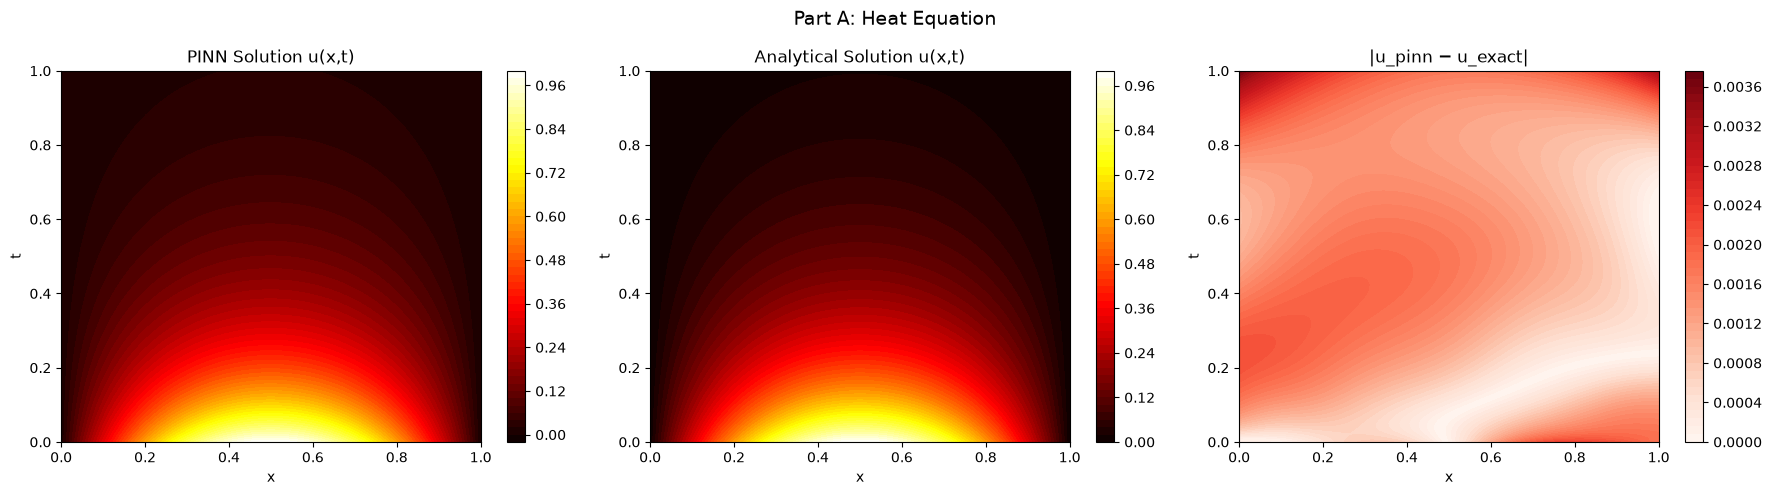

Part A — Final L² Relative Error: 0.001657


In [8]:
# Create test grid
x_vals = np.linspace(0, 1, 100)
t_vals = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_vals, t_vals)
XT = np.column_stack([X.ravel(), T.ravel()])

# Predictions
u_pinn = model_heat.predict(XT).reshape(100, 100)
u_exact = heat_exact(XT).reshape(100, 100)
u_error = np.abs(u_pinn - u_exact)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Part A: Heat Equation", fontsize=14)

im1 = axes[0].contourf(X, T, u_pinn, levels=50, cmap="hot")
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("PINN Solution u(x,t)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")

im2 = axes[1].contourf(X, T, u_exact, levels=50, cmap="hot")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title("Analytical Solution u(x,t)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")

im3 = axes[2].contourf(X, T, u_error, levels=50, cmap="Reds")
plt.colorbar(im3, ax=axes[2])
axes[2].set_title("|u_pinn − u_exact|")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")

plt.tight_layout()
plt.show()

final_l2 = train_state_heat.best_metrics[0]
print(f"Part A — Final L² Relative Error: {final_l2:.6f}")


In [9]:
collocation_counts = [500, 1000, 2500, 5000, 10000]
l2_errors = []

for n in collocation_counts:
    print(f"\nTraining with {n} collocation points...")
    dde.config.set_random_seed(42)

    _, _, train_state_b = solve_heat(
        num_domain=n,
        num_boundary=80,
        num_initial=160,
        iterations=8000
    )

    l2 = train_state_b.best_metrics[0]
    l2_errors.append(l2)
    print(f"  → L² error: {l2:.6f}")



Training with 500 collocation points...
Compiling model...
'compile' took 0.000102 s

Training model...

Step      Train loss                                  Test loss                                   Test metric   
0         [1.20e-02, 3.19e-03, 1.08e-02, 5.27e-01]    [1.09e-02, 3.19e-03, 1.08e-02, 5.27e-01]    [1.15e+00]    
2000      [1.31e-04, 3.43e-06, 2.20e-05, 1.72e-05]    [1.01e-04, 3.43e-06, 2.20e-05, 1.72e-05]    [8.59e-03]    
4000      [2.63e-03, 7.50e-05, 1.15e-04, 3.36e-05]    [1.51e-03, 7.50e-05, 1.15e-04, 3.36e-05]    [4.35e-02]    
6000      [1.69e-05, 6.40e-07, 1.10e-06, 7.97e-07]    [1.78e-05, 6.40e-07, 1.10e-06, 7.97e-07]    [2.24e-03]    
8000      [1.13e-05, 4.04e-07, 4.28e-07, 3.86e-07]    [1.17e-05, 4.04e-07, 4.28e-07, 3.86e-07]    [1.76e-03]    

Best model at step 8000:
  train loss: 1.25e-05
  test loss: 1.29e-05
  test metric: [1.76e-03]

'train' took 42.866354 s

  → L² error: 0.001762

Training with 1000 collocation points...
Compiling model...
'compile

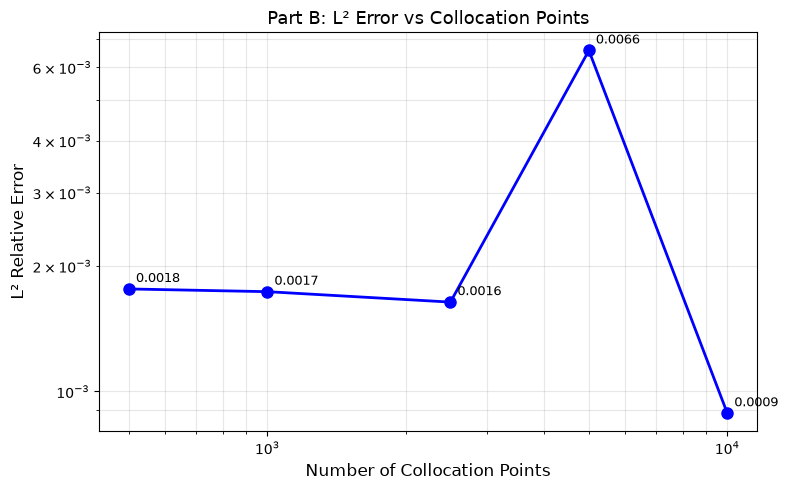


Results:
     500 points → L² error: 0.001762
    1000 points → L² error: 0.001736
    2500 points → L² error: 0.001639
    5000 points → L² error: 0.006584
   10000 points → L² error: 0.000886


In [10]:
plt.figure(figsize=(8, 5))
plt.plot(collocation_counts, l2_errors, "bo-", linewidth=2, markersize=8)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Number of Collocation Points", fontsize=12)
plt.ylabel("L² Relative Error", fontsize=12)
plt.title("Part B: L² Error vs Collocation Points", fontsize=13)
plt.grid(True, which="both", alpha=0.3)
for n, e in zip(collocation_counts, l2_errors):
    plt.annotate(f"{e:.4f}", (n, e), textcoords="offset points", xytext=(5, 5), fontsize=9)
plt.tight_layout()
plt.show()

print("\nResults:")
for n, e in zip(collocation_counts, l2_errors):
    print(f"  {n:6d} points → L² error: {e:.6f}")


In [11]:
def wave_pde(x, y):
    """PDE residual: uₜₜ - u_xx = 0"""
    dy_tt = dde.grad.hessian(y, x, j=1)   
    dy_xx = dde.grad.hessian(y, x, j=0)   
    return dy_tt - dy_xx

def wave_exact(x):
    """Analytical solution: sin(πx)*cos(πt)"""
    return np.sin(np.pi * x[:, 0:1]) * np.cos(np.pi * x[:, 1:2])


In [12]:
geom = dde.geometry.Interval(0, 1)
timedomain = dde.geometry.TimeDomain(0, 1)
geom_time_wave = dde.geometry.GeometryXTime(geom, timedomain)

bc_left_wave = dde.icbc.DirichletBC(geom_time_wave, lambda x: 0, boundary_left)
bc_right_wave = dde.icbc.DirichletBC(geom_time_wave, lambda x: 0, boundary_right)

ic_u = dde.icbc.IC(
    geom_time_wave,
    lambda x: np.sin(np.pi * x[:, 0:1]),
    lambda x, on_initial: on_initial
)

ic_ut = dde.icbc.OperatorBC(
    geom_time_wave,
    lambda x, y, _: dde.grad.jacobian(y, x, j=1), 
    lambda x, on_initial: on_initial
)

data_wave = dde.data.TimePDE(
    geom_time_wave,
    wave_pde,
    [bc_left_wave, bc_right_wave, ic_u, ic_ut],
    num_domain=5000,
    num_boundary=200,
    num_initial=200,
    solution=wave_exact,
    num_test=10000
)

net_wave = dde.nn.FNN([2] + [50] * 4 + [1], "tanh", "Glorot uniform")
model_wave = dde.Model(data_wave, net_wave)
model_wave.compile("adam", lr=1e-3, metrics=["l2 relative error"])
losshistory_wave, train_state_wave = model_wave.train(iterations=15000, display_every=3000)


Compiling model...
'compile' took 0.000127 s

Training model...

Step      Train loss                                            Test loss                                             Test metric   
0         [9.71e-04, 2.84e-02, 1.81e-01, 3.26e-01, 6.14e-02]    [9.57e-04, 2.84e-02, 1.81e-01, 3.26e-01, 6.14e-02]    [1.28e+00]    
3000      [2.65e-03, 2.99e-04, 3.85e-04, 4.61e-03, 1.86e-03]    [2.63e-03, 2.99e-04, 3.85e-04, 4.61e-03, 1.86e-03]    [1.36e+00]    
6000      [1.80e-03, 1.15e-04, 8.08e-06, 1.59e-03, 1.10e-03]    [1.79e-03, 1.15e-04, 8.08e-06, 1.59e-03, 1.10e-03]    [1.34e+00]    
9000      [5.65e-03, 1.60e-04, 6.98e-04, 1.86e-03, 2.57e-03]    [5.43e-03, 1.60e-04, 6.98e-04, 1.86e-03, 2.57e-03]    [1.34e+00]    
12000     [7.48e-04, 6.16e-05, 2.44e-05, 5.23e-04, 6.37e-04]    [6.80e-04, 6.16e-05, 2.44e-05, 5.23e-04, 6.37e-04]    [1.33e+00]    
15000     [5.68e-03, 1.13e-04, 5.91e-04, 1.30e-03, 5.01e-03]    [5.74e-03, 1.13e-04, 5.91e-04, 1.30e-03, 5.01e-03]    [1.34e+00]    

Bes

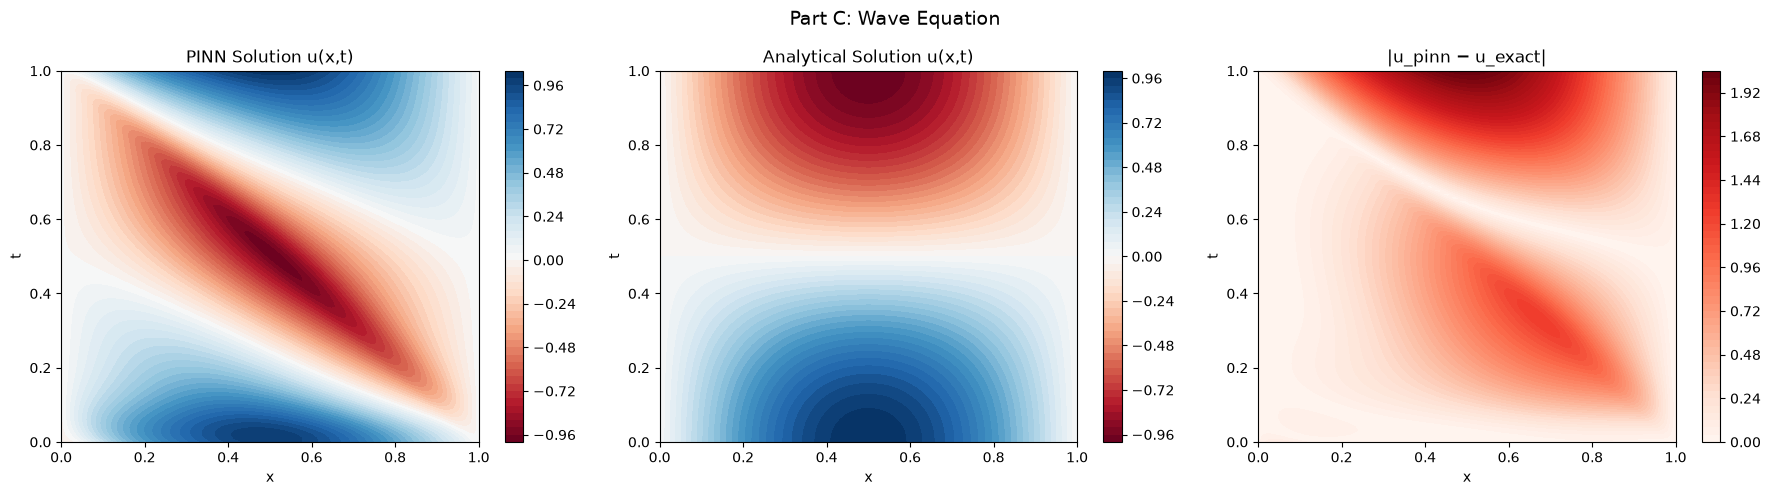

Part C — Final L² Relative Error: 1.326859


In [13]:
u_wave_pinn = model_wave.predict(XT).reshape(100, 100)
u_wave_exact = wave_exact(XT).reshape(100, 100)
u_wave_error = np.abs(u_wave_pinn - u_wave_exact)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Part C: Wave Equation", fontsize=14)

im1 = axes[0].contourf(X, T, u_wave_pinn, levels=50, cmap="RdBu")
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("PINN Solution u(x,t)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")

im2 = axes[1].contourf(X, T, u_wave_exact, levels=50, cmap="RdBu")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title("Analytical Solution u(x,t)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")

im3 = axes[2].contourf(X, T, u_wave_error, levels=50, cmap="Reds")
plt.colorbar(im3, ax=axes[2])
axes[2].set_title("|u_pinn − u_exact|")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")

plt.tight_layout()
plt.show()

wave_l2 = train_state_wave.best_metrics[0]
print(f"Part C — Final L² Relative Error: {wave_l2:.6f}")
